RMS spot radii (microns)
--------------------------------------------------
Spherical mirror   | offset =   0.0 mm | RMS =  502.358 um
Spherical mirror   | offset =   5.0 mm | RMS =  511.019 um
Spherical mirror   | offset =  10.0 mm | RMS =  536.780 um
Spherical mirror   | offset =  15.0 mm | RMS =  578.718 um
Parabolic mirror   | offset =   0.0 mm | RMS =    0.000 um
Parabolic mirror   | offset =   5.0 mm | RMS =   65.428 um
Parabolic mirror   | offset =  10.0 mm | RMS =  132.829 um
Parabolic mirror   | offset =  15.0 mm | RMS =  204.065 um


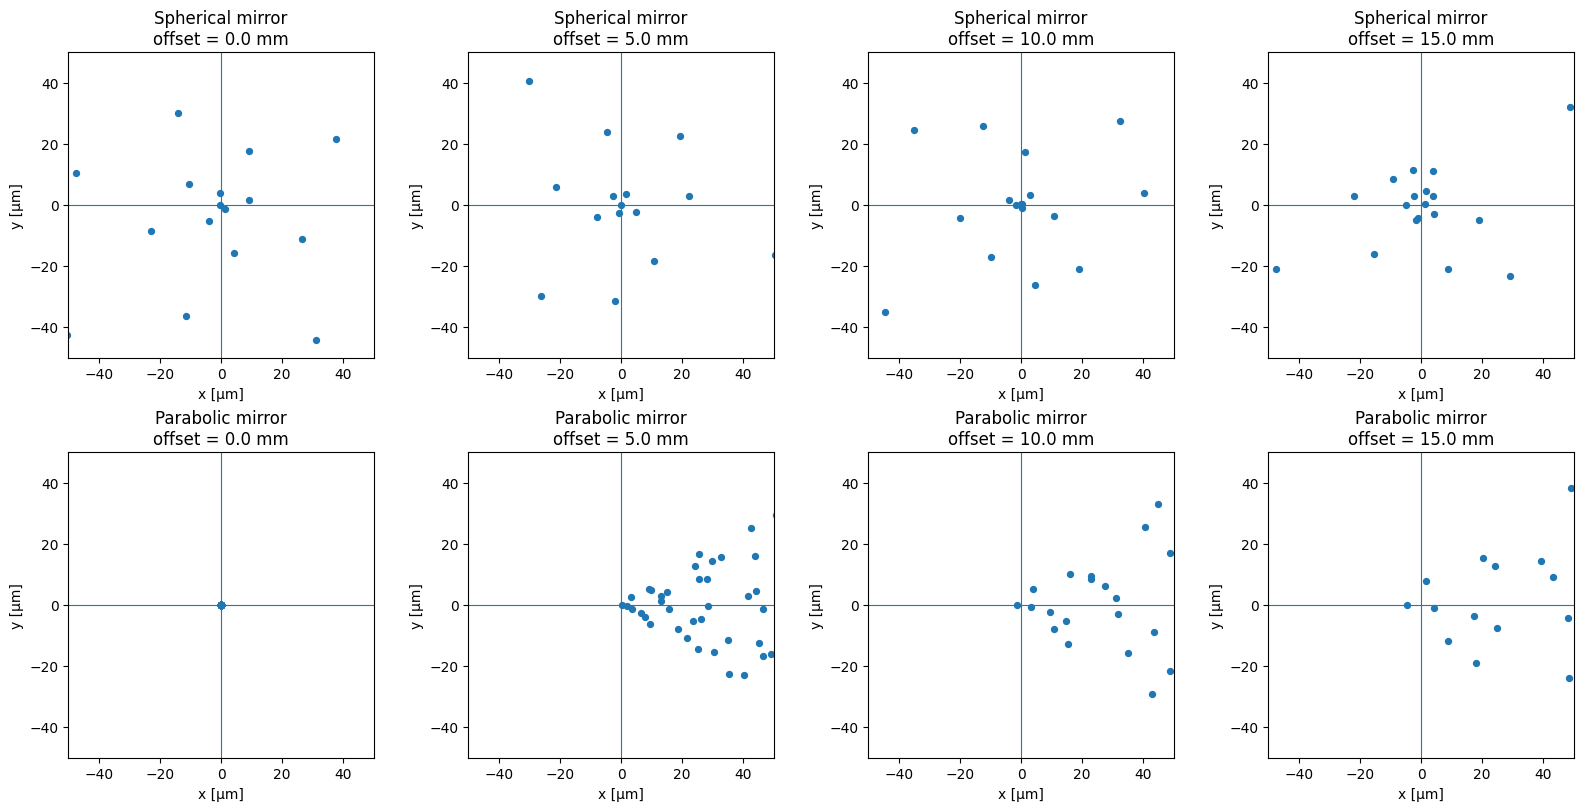

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
R = 1000.0          # radius of curvature [mm]
D = 250.0           # aperture diameter [mm]
a = D / 2.0         # aperture radius [mm]
f = R / 2.0         # paraxial focal length [mm] = 500 mm
n_rays = 100
offsets_mm = [0.0, 5.0, 10.0, 15.0]

# Plot window for spot diagrams: +/- 50 um = 100 um total width
plot_half_width_um = 50.0


# ------------------------------------------------------------
# Ray sampling over circular aperture
# ------------------------------------------------------------
def sample_circular_aperture(n, radius):
    golden_angle = np.pi * (3 - np.sqrt(5))
    k = np.arange(n)
    r = radius * np.sqrt((k + 0.5) / n)
    theta = k * golden_angle
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y])


# ------------------------------------------------------------
# General conic sag surface and normal
#
# Sag equation:
#   z(r) = r^2 / ( R * (1 + sqrt(1 - (1+k) r^2 / R^2)) )
#
# where:
#   k = 0    -> sphere
#   k = -1   -> paraboloid
#
# Surface is z = z(x,y), so a surface normal can be formed from
#   n ~ (-dz/dx, -dz/dy, 1)
# ------------------------------------------------------------
def conic_surface_and_normal(x, y, R, k):
    r2 = x*x + y*y
    A = 1.0 + k

    # Guard against numerical issues outside the valid conic domain
    arg = 1.0 - A * r2 / (R*R)
    if arg < 0:
        raise ValueError("Point lies outside valid conic domain")

    s = np.sqrt(arg)

    # Sag
    z = r2 / (R * (1.0 + s))

    # Radial derivative dz/dr
    r = np.sqrt(r2)
    if r < 1e-15:
        dzdx = 0.0
        dzdy = 0.0
    else:
        # z = r^2 / (R(1+s)),  s = sqrt(1 - A r^2/R^2)
        # derivative wrt r:
        # dz/dr = 2r/(R(1+s)) + (A r^3)/(R^3 s (1+s)^2)
        dzdr = (2.0 * r) / (R * (1.0 + s)) + (A * r**3) / (R**3 * s * (1.0 + s)**2)

        dzdx = dzdr * (x / r)
        dzdy = dzdr * (y / r)

    n = np.array([-dzdx, -dzdy, 1.0], dtype=float)
    n /= np.linalg.norm(n)

    return np.array([x, y, z]), n


# ------------------------------------------------------------
# Reflection
# ------------------------------------------------------------
def reflect(d_in, n):
    return d_in - 2.0 * np.dot(d_in, n) * n


# ------------------------------------------------------------
# Trace a ray bundle for a given field offset
# offset = desired paraxial image height at z=f
# theta = arctan(offset / f)
# Incoming direction lies in x-z plane
# ------------------------------------------------------------
def trace_spot(aperture_pts, conic_k, field_offset_mm):
    theta = np.arctan(field_offset_mm / f)
    d_in = np.array([np.sin(theta), 0.0, -np.cos(theta)], dtype=float)

    hits = []

    for x, y in aperture_pts:
        p, n = conic_surface_and_normal(x, y, R, conic_k)
        d_out = reflect(d_in, n)

        # Intersect reflected ray with plane z = f
        if abs(d_out[2]) < 1e-12:
            continue

        t = (f - p[2]) / d_out[2]
        hit = p + t * d_out
        hits.append(hit)

    hits = np.array(hits)

    # Ideal paraxial image point at z=f
    ideal_x = field_offset_mm
    ideal_y = 0.0

    # Spot coordinates relative to ideal point, in microns
    sx_um = (hits[:, 0] - ideal_x) * 1000.0
    sy_um = (hits[:, 1] - ideal_y) * 1000.0

    return sx_um, sy_um, hits


# ------------------------------------------------------------
# RMS spot radius about centroid
# ------------------------------------------------------------
def rms_radius_um(x_um, y_um):
    xc = np.mean(x_um)
    yc = np.mean(y_um)
    return np.sqrt(np.mean((x_um - xc)**2 + (y_um - yc)**2))


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
if __name__ == "__main__":
    aperture_pts = sample_circular_aperture(n_rays, a)

    mirrors = [
        {"name": "Spherical mirror", "k": 0.0},
        {"name": "Parabolic mirror", "k": -1.0},
    ]

    fig, axes = plt.subplots(
        len(mirrors),
        len(offsets_mm),
        figsize=(4 * len(offsets_mm), 4 * len(mirrors)),
        constrained_layout=True
    )

    if len(mirrors) == 1 and len(offsets_mm) == 1:
        axes = np.array([[axes]])
    elif len(mirrors) == 1:
        axes = np.array([axes])
    elif len(offsets_mm) == 1:
        axes = np.array([[ax] for ax in axes])

    print("RMS spot radii (microns)")
    print("-" * 50)

    for i, mirror in enumerate(mirrors):
        for j, offset in enumerate(offsets_mm):
            sx_um, sy_um, hits = trace_spot(aperture_pts, mirror["k"], offset)
            rms_um = rms_radius_um(sx_um, sy_um)

            print(f"{mirror['name']:18s} | offset = {offset:5.1f} mm | RMS = {rms_um:8.3f} um")

            ax = axes[i, j]
            ax.scatter(sx_um, sy_um, s=18)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xlim(-plot_half_width_um, plot_half_width_um)
            ax.set_ylim(-plot_half_width_um, plot_half_width_um)
            ax.axhline(0, linewidth=0.8)
            ax.axvline(0, linewidth=0.8)
            ax.set_title(f"{mirror['name']}\noffset = {offset:.1f} mm")
            ax.set_xlabel("x [µm]")
            ax.set_ylabel("y [µm]")

    plt.show()



Q1: the focalpoint f is located at R/2.0 so 500mm

Q2: Comparison of spherical vs. parabolic mirror spot diagrams

On-axis case (offset = 0 mm)

For the parabolic mirror, all rays converge to exactly the same point at the center of the diagram. This indicates that the parabolic mirror brings parallel incoming rays to a perfect focus on-axis.

For the spherical mirror, the rays do not converge to a single point and instead form a spread-out spot. This shows that the different hit points have different focus points even at the 0 offset

Off-axis cases (offset = 5 mm, 10 mm, 15 mm)

As the field offset increases, both mirrors begin to show larger and more asymmetric spots.

For the parabolic mirror, the spots remain relatively tight but become skewed as the offset increases. 

For the spherical mirror, the spots are generally more spread out and less well focused across all offsets.

Overall comparison

The parabolic mirror performs significantly better on-axis, producing a nearly perfect point focus, while the spherical mirror produces a blurred spot due to spherical aberration. Off-axis, both mirrors show increasing aberrations, but the parabolic mirror still produces smaller and more concentrated spots compared to the spherical mirror.

Therefore, the parabolic mirror provides better image quality overall, which explains why Newtonian reflector telescopes use parabolic primary mirrors instead of spherical ones.